<a href="https://colab.research.google.com/github/SSenitha/Data_Analytics/blob/Aashi/Group_2_predictiveAnalysis_fc211015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analysis of Rain in Australia
This notebook contains all the steps of the analysis: From data cleaning and preprocessing to the conclusions.

In [1]:
# Load data from the repository
!wget https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv

--2025-09-18 14:00:40--  https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14094055 (13M) [text/plain]
Saving to: ‘weatherAUS.csv’

weatherAUS.csv      100%[===================>]  13.44M  --.-KB/s    in 0.1s    

2025-09-18 14:00:40 (106 MB/s) - ‘weatherAUS.csv’ saved [14094055/14094055]



In [2]:
#Import necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

#Data Cleaning

In [3]:
# Read the dataset and output the total count
df = pd.read_csv('/content/weatherAUS.csv')
print(f"Total rows count: {df['RainToday'].count()}")
df.head()

Total rows count: 142199


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


##1. De-duplication

In [4]:
# Check for duplicate rows and removing, keeping the first occurrence
print(df.duplicated().sum())
df_cleaned = df.drop_duplicates()

0


##2. Null Value Handeling

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
# Check for the missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Calculate the percent of data that is missing
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(f"Percentage of missing values: {percent_missing}")

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64
Percentage of missing values: 10.259745694319072


In [7]:
df_cleaned = df

# Remove the rows that has missing result
df_cleaned.dropna(subset=['RainToday'], inplace=True)
df_cleaned.dropna(subset=['RainTomorrow'], inplace=True)
#print(df.head())

# Check the remaining value count
print(f"Total rows Left: {df['RainToday'].count()}")

Total rows Left: 140787


In [8]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('')

##3. Standardization

In [9]:
# convert the date column into a datetime object
df_cleaned['Date'] = pd.to_datetime(df['Date'], format="%Y-%m-%d")

# extract the day, month, and year components
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

In [10]:
#Removing unwanted columns
df_cleaned.drop(['Date'], axis=1, inplace=True)
df_cleaned.drop(['WindGustDir'], axis=1, inplace=True)
df_cleaned.drop(['WindDir9am'], axis=1, inplace=True)
df_cleaned.drop(['WindDir3pm'], axis=1, inplace=True)

In [11]:
# Map binary variables
df_cleaned['RainTomorrow'] = df_cleaned['RainTomorrow'].map({'Yes': 1, 'No': 0})
df_cleaned['RainToday'] = df_cleaned['RainToday'].map({'Yes': 1, 'No': 0})

In [12]:
df_cleaned.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,Albury,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,Albury,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,Albury,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,Albury,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,Albury,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


# Predictive Analysis

Encoding Categorical Variables

In [13]:
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

label_encoder = LabelEncoder()

for col in categorical_cols:
  df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

print("\nData types after encoding:")
print(df_cleaned.dtypes)
df_cleaned.head()

Categorical columns to encode: ['Location']

Data types after encoding:
Location           int64
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustSpeed    float64
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday          int64
RainTomorrow       int64
Day                int32
Month              int32
Year               int32
dtype: object


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Day,Month,Year
0,2,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,...,1007.1,8.0,5.0,16.9,21.8,0,0,1,12,2008
1,2,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,...,1007.8,5.0,5.0,17.2,24.3,0,0,2,12,2008
2,2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,...,1008.7,5.0,2.0,21.0,23.2,0,0,3,12,2008
3,2,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,...,1012.8,5.0,5.0,18.1,26.5,0,0,4,12,2008
4,2,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,...,1006.0,7.0,8.0,17.8,29.7,0,0,5,12,2008


Define Features (X) and Target (Y)

In [14]:
y = df_cleaned['RainTomorrow']

X = df_cleaned.drop(['RainTomorrow', 'RainToday'], axis=1)

print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)

Shape of Features (X): (140787, 20)
Shape of Target (y): (140787,)


Data Splitting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


Training set size: 112629 rows
Testing set size: 28158 rows


Scaling Features

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the model

In [17]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

print("Training Logistic Regression...")
log_reg.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf.fit(X_train_scaled, y_train)

print("Training XGBoost...")
xgb.fit(X_train_scaled, y_train)

print("All models trained successfully!")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
All models trained successfully!


Evaluate Model Performances

In [18]:
y_pred_log_reg = log_reg.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

def evaluate_model(model_name, y_true, y_pred):
    print(f"\n\033[1m{model_name} Performance:\033[0m")
    accuracy = accuracy_score(y_true, y_pred)
    print("Accuracy:", round(accuracy, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    roc_auc = roc_auc_score(y_true, y_pred)
    print("ROC-AUC Score:", round(roc_auc, 4))
    print("----------------------------------")

evaluate_model("Logistic Regression", y_test, y_pred_log_reg)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)


Logistic Regression Performance:
Accuracy: 0.8414

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     21897
           1       0.72      0.47      0.57      6261

    accuracy                           0.84     28158
   macro avg       0.79      0.71      0.74     28158
weighted avg       0.83      0.84      0.83     28158

ROC-AUC Score: 0.7102
----------------------------------

Random Forest Performance:
Accuracy: 0.8562

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     21897
           1       0.77      0.50      0.61      6261

    accuracy                           0.86     28158
   macro avg       0.82      0.73      0.76     28158
weighted avg       0.85      0.86      0.84     28158

ROC-AUC Score: 0.7304
----------------------------------

XGBoost Performance:
Accuracy: 0.8601

Classification Report:
              precision  

Addressing Class Imbalance

In [19]:
from sklearn.utils import class_weight

classes = np.unique(y_train)
class_weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weights_dict)

log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight=class_weights_dict)
rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight=class_weights_dict)
xgb_balanced = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=class_weights_dict[1])

print("Training balanced models...")
log_reg_balanced.fit(X_train_scaled, y_train)
rf_balanced.fit(X_train_scaled, y_train)
xgb_balanced.fit(X_train_scaled, y_train)
print("Balanced models trained!")

Class weights: {np.int64(0): np.float64(0.6422071183386742), np.int64(1): np.float64(2.257999198075381)}
Training balanced models...
Balanced models trained!


Evaluating the Balanced Module

In [20]:
y_pred_log_reg_bal = log_reg_balanced.predict(X_test_scaled)
y_pred_rf_bal = rf_balanced.predict(X_test_scaled)
y_pred_xgb_bal = xgb_balanced.predict(X_test_scaled)

print("\n\033[1m=== BALANCED MODEL RESULTS ===\033[0m")
evaluate_model("Balanced Logistic Regression", y_test, y_pred_log_reg_bal)
evaluate_model("Balanced Random Forest", y_test, y_pred_rf_bal)
evaluate_model("Balanced XGBoost", y_test, y_pred_xgb_bal)


=== BALANCED MODEL RESULTS ===

Balanced Logistic Regression Performance:
Accuracy: 0.7897

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.85     21897
           1       0.52      0.77      0.62      6261

    accuracy                           0.79     28158
   macro avg       0.72      0.78      0.74     28158
weighted avg       0.83      0.79      0.80     28158

ROC-AUC Score: 0.7813
----------------------------------

Balanced Random Forest Performance:
Accuracy: 0.8534

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     21897
           1       0.78      0.47      0.59      6261

    accuracy                           0.85     28158
   macro avg       0.82      0.72      0.75     28158
weighted avg       0.85      0.85      0.84     28158

ROC-AUC Score: 0.7168
----------------------------------

Balanced XGBoost Performance:
Accurac

Using Different Probability Thresholds

In [21]:
y_proba_xgb = xgb_balanced.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.4, 0.5]
for threshold in thresholds:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)
    print(f"\n\033[1mXGBoost with threshold {threshold}:\033[0m")
    print("Recall for 'Rain' class:", classification_report(y_test, y_pred_threshold, output_dict=True)['1']['recall'])
    print("Precision for 'Rain' class:", classification_report(y_test, y_pred_threshold, output_dict=True)['1']['precision'])


XGBoost with threshold 0.3:
Recall for 'Rain' class: 0.855933556939786
Precision for 'Rain' class: 0.5037601052829479

XGBoost with threshold 0.4:
Recall for 'Rain' class: 0.7808656764095192
Precision for 'Rain' class: 0.5737589484802254

XGBoost with threshold 0.5:
Recall for 'Rain' class: 0.702283980194857
Precision for 'Rain' class: 0.6427422891390148


Feature Importance Analysis

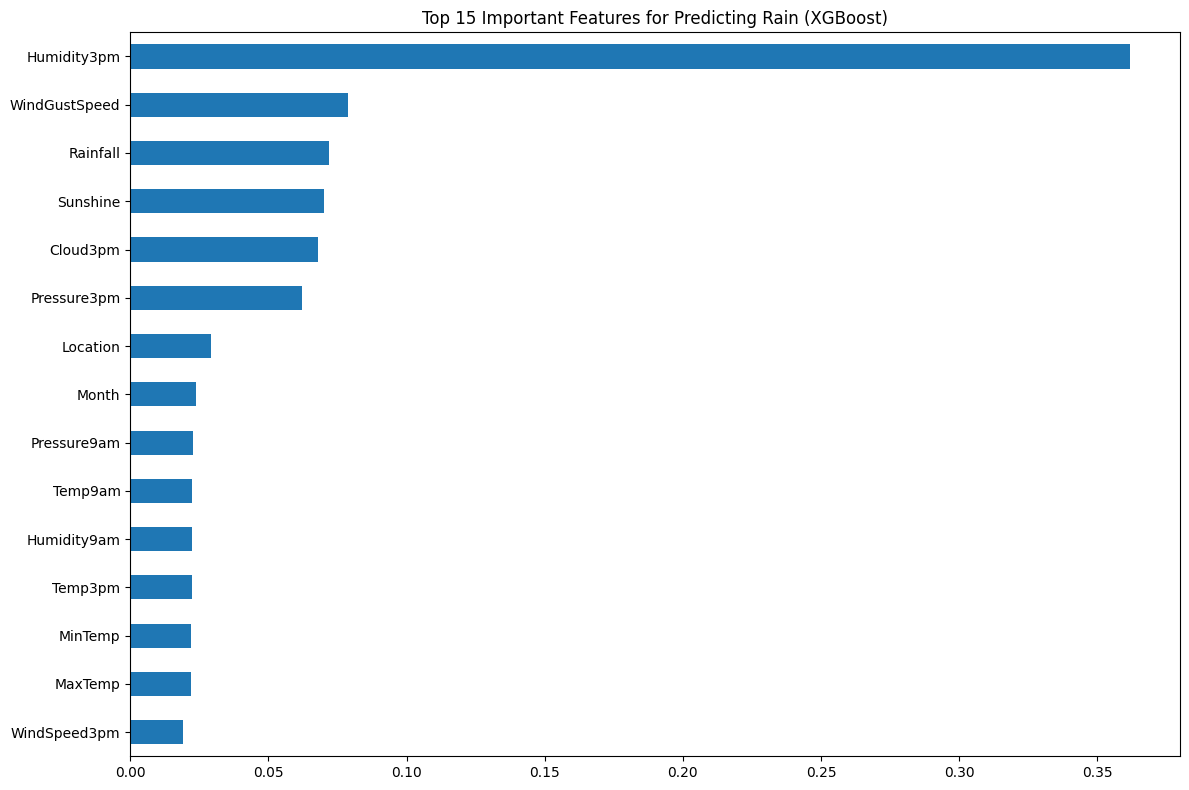

In [22]:
plt.figure(figsize=(12, 8))
feature_importances = pd.Series(xgb_balanced.feature_importances_, index=X.columns)
feature_importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Top 15 Important Features for Predicting Rain (XGBoost)')
plt.tight_layout()
plt.show()

Confusion Matrix

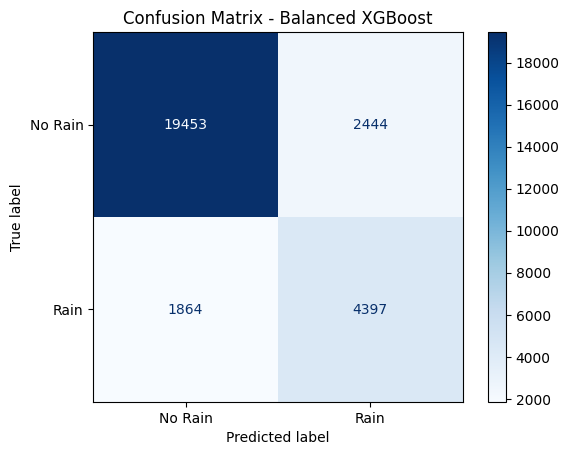

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Balanced XGBoost')
plt.show()

Hyperparameter Tuning (XGBoost)

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'scale_pos_weight': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("Starting grid search...")
grid_search.fit(X_train_scaled, y_train)
print("Grid search complete!")

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score from cross-validation: {grid_search.best_score_:.4f}")

best_xgb_model = grid_search.best_estimator_

Starting grid search...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Grid search complete!

Best parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'scale_pos_weight': 3}
Best ROC-AUC score from cross-validation: 0.8911


Final Evaluation of the Tuned Model

In [25]:
y_pred_best_xgb = best_xgb_model.predict(X_test_scaled)
y_proba_best_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\n\033[1m=== TUNED XGBoost Model Results ===\033[0m")
evaluate_model("Tuned XGBoost", y_test, y_pred_best_xgb)

roc_auc_best = roc_auc_score(y_test, y_proba_best_xgb)
print(f"ROC-AUC Score (with probabilities): {roc_auc_best:.4f}")


=== TUNED XGBoost Model Results ===

Tuned XGBoost Performance:
Accuracy: 0.8491

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     21897
           1       0.65      0.70      0.67      6261

    accuracy                           0.85     28158
   macro avg       0.78      0.80      0.79     28158
weighted avg       0.85      0.85      0.85     28158

ROC-AUC Score: 0.7961
----------------------------------
ROC-AUC Score (with probabilities): 0.8942


Analyze the Best Model Behaviour

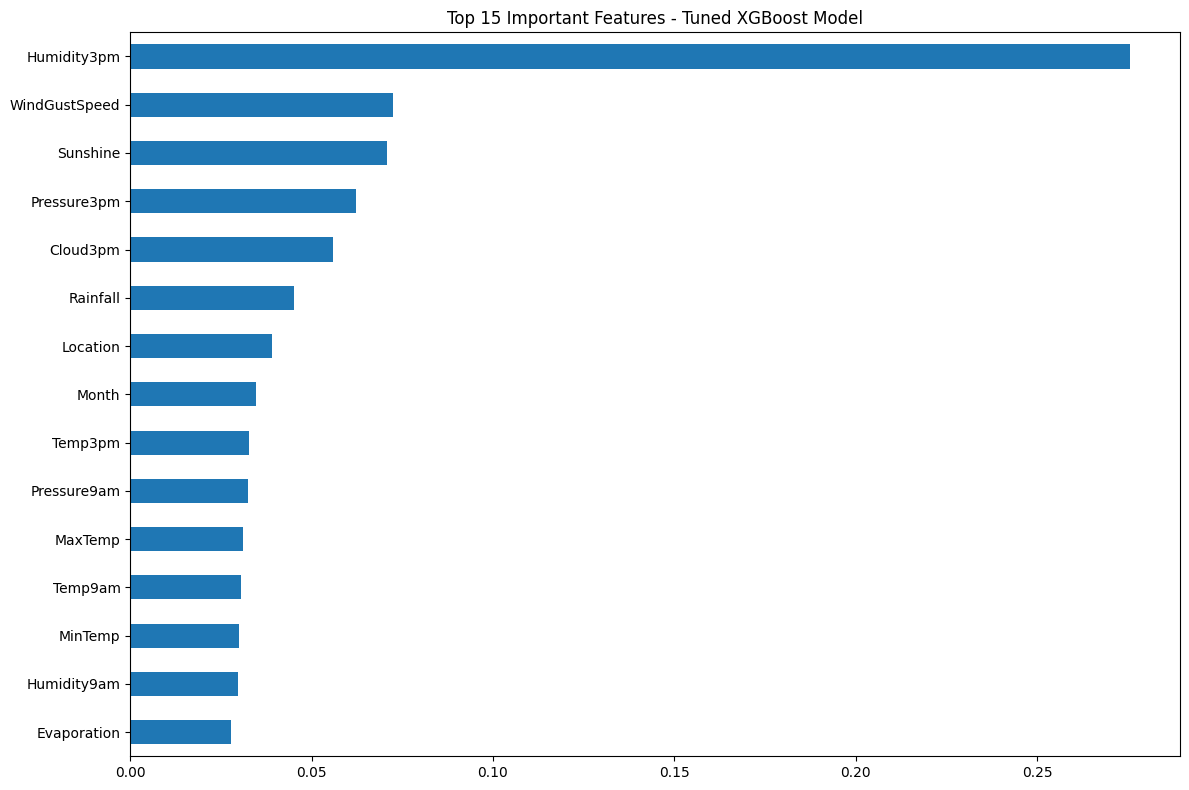

Top 10 Most Important Features for Predicting RainTomorrow:
Humidity3pm      0.275664
WindGustSpeed    0.072479
Sunshine         0.070663
Pressure3pm      0.062163
Cloud3pm         0.055929
Rainfall         0.045037
Location         0.038989
Month            0.034695
Temp3pm          0.032762
Pressure9am      0.032421
dtype: float32


In [26]:
plt.figure(figsize=(12, 8))
importances = pd.Series(best_xgb_model.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind='barh')
plt.title('Top 15 Important Features - Tuned XGBoost Model')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features for Predicting RainTomorrow:")
print(importances.nlargest(10))

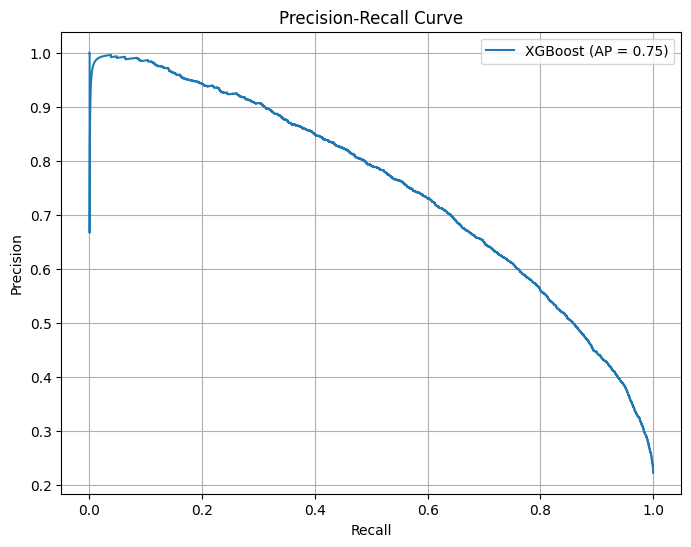

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best_xgb)
average_precision = average_precision_score(y_test, y_proba_best_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'XGBoost (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Sample Predictions

In [28]:
print("=== DEBUGGING FEATURE MISMATCH ===")
print(f"Number of features in X_train: {X_train.shape[1]}")
print(f"Number of features scaler expects: {scaler.n_features_in_}")
print("\nList of all features the model is actually using:")
print(X.columns.tolist())
print(f"\nTotal features: {len(X.columns)}")

=== DEBUGGING FEATURE MISMATCH ===
Number of features in X_train: 20
Number of features scaler expects: 20

List of all features the model is actually using:
['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Day', 'Month', 'Year']

Total features: 20


In [29]:
print("=== MAKING A SAMPLE PREDICTION ===")

sample_data = {}
for feature in X.columns:
    sample_data[feature] = [X_train[feature].median()]

new_data_df = pd.DataFrame(sample_data)
print("Sample data point (median values for all features):")
print(new_data_df)

new_data_scaled = scaler.transform(new_data_df)

prediction = best_xgb_model.predict(new_data_scaled)
prediction_proba = best_xgb_model.predict_proba(new_data_scaled)

print(f"\nPrediction for 'average' conditions:")
print(f"Probability of No Rain: {prediction_proba[0][0]:.2%}")
print(f"Probability of Rain: {prediction_proba[0][1]:.2%}")
print(f"Final Prediction: {'Rain Tomorrow' if prediction[0] == 1 else 'No Rain Tomorrow'}")

=== MAKING A SAMPLE PREDICTION ===
Sample data point (median values for all features):
   Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0      24.0     12.0     22.6       0.0          4.8       8.5           39.0   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
0          13.0          19.0         70.0         52.0       1017.6   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm   Day  Month    Year  
0       1015.2       5.0       5.0     16.7     21.1  16.0    6.0  2013.0  

Prediction for 'average' conditions:
Probability of No Rain: 69.05%
Probability of Rain: 30.95%
Final Prediction: No Rain Tomorrow


In [30]:
print("\n=== TESTING A 'RAINY' SCENARIO ===")

rainy_scenario = sample_data.copy()

if 'Humidity3pm' in rainy_scenario:
    rainy_scenario['Humidity3pm'] = [90]
if 'Pressure3pm' in rainy_scenario:
    rainy_scenario['Pressure3pm'] = [990]
if 'Cloud3pm' in rainy_scenario:
    rainy_scenario['Cloud3pm'] = [8]

rainy_df = pd.DataFrame(rainy_scenario)
rainy_scaled = scaler.transform(rainy_df)
rainy_pred = best_xgb_model.predict(rainy_scaled)
rainy_proba = best_xgb_model.predict_proba(rainy_scaled)

print("Sample data point for 'rainy' conditions:")
print(rainy_df[['Humidity3pm', 'Pressure3pm', 'Cloud3pm']])
print(f"\nPrediction for 'rainy' conditions:")
print(f"Probability of No Rain: {rainy_proba[0][0]:.2%}")
print(f"Probability of Rain: {rainy_proba[0][1]:.2%}")
print(f"Final Prediction: {'Rain Tomorrow' if rainy_pred[0] == 1 else 'No Rain Tomorrow'}")


=== TESTING A 'RAINY' SCENARIO ===
Sample data point for 'rainy' conditions:
   Humidity3pm  Pressure3pm  Cloud3pm
0           90          990         8

Prediction for 'rainy' conditions:
Probability of No Rain: 1.23%
Probability of Rain: 98.77%
Final Prediction: Rain Tomorrow


Streamlit

In [31]:
import joblib

# Save the trained model
joblib.dump(best_xgb_model, 'rainfall_predictor_model.pkl')  # Or use your tuned model variable

# Save the fitted scaler
joblib.dump(scaler, 'fitted_scaler.pkl')

# Save the feature list (Crucial for knowing the correct column order later)
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Model, scaler, and feature list saved successfully!")

Model, scaler, and feature list saved successfully!
